In [2]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
from scipy.stats import pearsonr

with open('calls_scored.json', 'r') as f:
    calls = json.load(f)

print(f"Loaded {len(calls)} calls")

Loaded 64 calls


In [3]:
rows = []
for call in calls:
    quality = call['type'].split('_')[-1]
    for criterion in ['policy_compliance', 'communication', 'resolution']:
        rows.append({
            'call_type': call['type'],
            'quality': quality,
            'criterion': criterion,
            'ai':     call['ai_score'][criterion],
            'human1': call['human1_score'][criterion],
            'human2': call['human2_score'][criterion],
        })

df = pd.DataFrame(rows)
print(df.head(10))

                       call_type    quality          criterion  ai  human1  \
0  balance_not_updated_ambiguous  ambiguous  policy_compliance   4       3   
1  balance_not_updated_ambiguous  ambiguous      communication   4       3   
2  balance_not_updated_ambiguous  ambiguous         resolution   3       3   
3        balance_not_updated_bad        bad  policy_compliance   3       2   
4        balance_not_updated_bad        bad      communication   1       1   
5        balance_not_updated_bad        bad         resolution   1       1   
6       balance_not_updated_good       good  policy_compliance   5       4   
7       balance_not_updated_good       good      communication   5       5   
8       balance_not_updated_good       good         resolution   5       5   
9       balance_not_updated_good       good  policy_compliance   5       5   

   human2  
0       3  
1       3  
2       4  
3       1  
4       2  
5       2  
6       5  
7       5  
8       4  
9       5  


In [4]:
df['mae_ai_h1']  = abs(df['ai'] - df['human1'])
df['mae_ai_h2']  = abs(df['ai'] - df['human2'])
df['mae_h1_h2']  = abs(df['human1'] - df['human2'])

print("=== Mean Absolute Error ===")
print(f"AI  vs Human1 : {df['mae_ai_h1'].mean():.3f}")
print(f"AI  vs Human2 : {df['mae_ai_h2'].mean():.3f}")
print(f"Human1 vs Human2 : {df['mae_h1_h2'].mean():.3f}")

=== Mean Absolute Error ===
AI  vs Human1 : 0.438
AI  vs Human2 : 0.531
Human1 vs Human2 : 0.583


In [5]:
print("=== Cohen's Kappa ===")
kappa_ai_h1  = cohen_kappa_score(df['ai'],     df['human1'])
kappa_ai_h2  = cohen_kappa_score(df['ai'],     df['human2'])
kappa_h1_h2  = cohen_kappa_score(df['human1'], df['human2'])

def interpret(k):
    if k < 0.20: return "Poor"
    elif k < 0.40: return "Fair"
    elif k < 0.60: return "Moderate"
    elif k < 0.80: return "Substantial"
    else: return "Almost Perfect"

print(f"AI  vs Human1 : {kappa_ai_h1:.3f}  ({interpret(kappa_ai_h1)})")
print(f"AI  vs Human2 : {kappa_ai_h2:.3f}  ({interpret(kappa_ai_h2)})")
print(f"Human1 vs Human2 : {kappa_h1_h2:.3f}  ({interpret(kappa_h1_h2)})")

=== Cohen's Kappa ===
AI  vs Human1 : 0.500  (Moderate)
AI  vs Human2 : 0.371  (Fair)
Human1 vs Human2 : 0.324  (Fair)


In [6]:
print("=== Pearson Correlation ===")
corr_ai_h1,  _ = pearsonr(df['ai'], df['human1'])
corr_ai_h2,  _ = pearsonr(df['ai'], df['human2'])
corr_h1_h2,  _ = pearsonr(df['human1'], df['human2'])

print(f"AI  vs Human1 : {corr_ai_h1:.3f}")
print(f"AI  vs Human2 : {corr_ai_h2:.3f}")
print(f"Human1 vs Human2 : {corr_h1_h2:.3f}")

=== Pearson Correlation ===
AI  vs Human1 : 0.843
AI  vs Human2 : 0.808
Human1 vs Human2 : 0.779


In [7]:
print("=== Per-Criterion MAE (AI vs Human Average) ===")
df['human_avg'] = (df['human1'] + df['human2']) / 2
df['mae_ai_havg'] = abs(df['ai'] - df['human_avg'])

summary = df.groupby('criterion')['mae_ai_havg'].mean()
print(summary.to_string())

=== Per-Criterion MAE (AI vs Human Average) ===
criterion
communication        0.445312
policy_compliance    0.531250
resolution           0.398438


In [8]:
print("=== Per-Quality Level MAE (AI vs Human Average) ===")
summary_q = df.groupby('quality')['mae_ai_havg'].mean().sort_values()
print(summary_q.to_string())

=== Per-Quality Level MAE (AI vs Human Average) ===
quality
good          0.322917
noise         0.333333
bad           0.444444
recovery      0.533333
ambiguous     0.574074
incomplete    0.629630


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

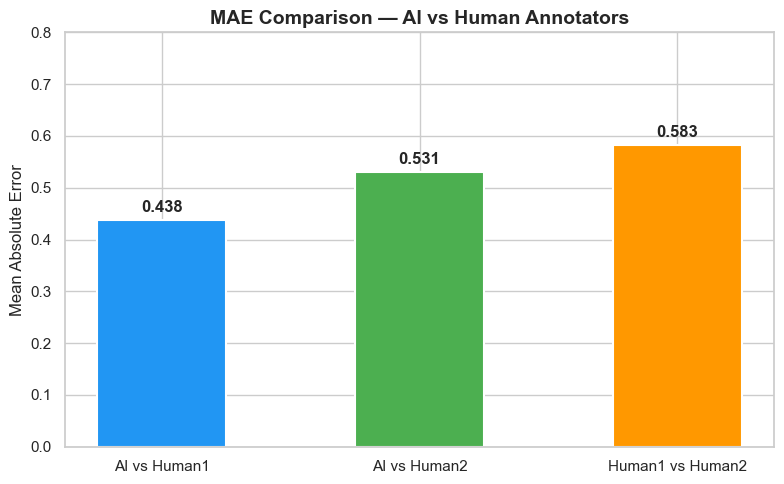

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['AI vs Human1', 'AI vs Human2', 'Human1 vs Human2']
values = [0.438, 0.531, 0.583]
colors = ['#2196F3', '#4CAF50', '#FF9800']

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 0.8)
ax.set_ylabel('Mean Absolute Error', fontsize=12)
ax.set_title('MAE Comparison — AI vs Human Annotators', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('mae_comparison.png', dpi=150)
plt.show()

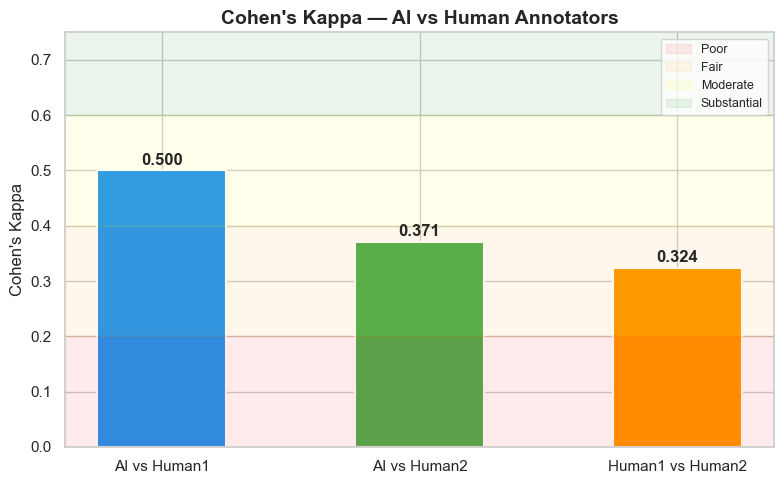

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['AI vs Human1', 'AI vs Human2', 'Human1 vs Human2']
values = [0.500, 0.371, 0.324]
colors = ['#2196F3', '#4CAF50', '#FF9800']

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Kappa interpretation bands
ax.axhspan(0.00, 0.20, alpha=0.08, color='red',    label='Poor')
ax.axhspan(0.20, 0.40, alpha=0.08, color='orange', label='Fair')
ax.axhspan(0.40, 0.60, alpha=0.08, color='yellow', label='Moderate')
ax.axhspan(0.60, 0.80, alpha=0.08, color='green',  label='Substantial')

ax.set_ylim(0, 0.75)
ax.set_ylabel("Cohen's Kappa", fontsize=12)
ax.set_title("Cohen's Kappa — AI vs Human Annotators", fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('kappa_comparison.png', dpi=150)
plt.show()

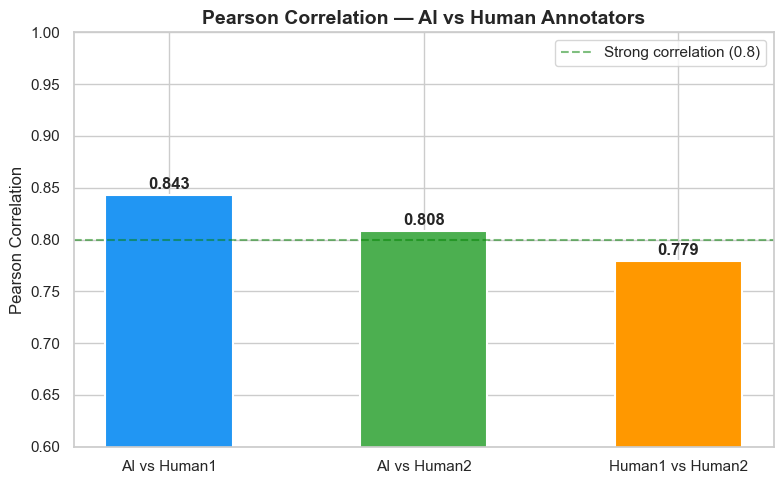

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['AI vs Human1', 'AI vs Human2', 'Human1 vs Human2']
values = [0.843, 0.808, 0.779]
colors = ['#2196F3', '#4CAF50', '#FF9800']

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Pearson Correlation', fontsize=12)
ax.set_title('Pearson Correlation — AI vs Human Annotators', fontsize=14, fontweight='bold')
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Strong correlation (0.8)')
ax.legend()
plt.tight_layout()
plt.savefig('correlation_comparison.png', dpi=150)
plt.show()

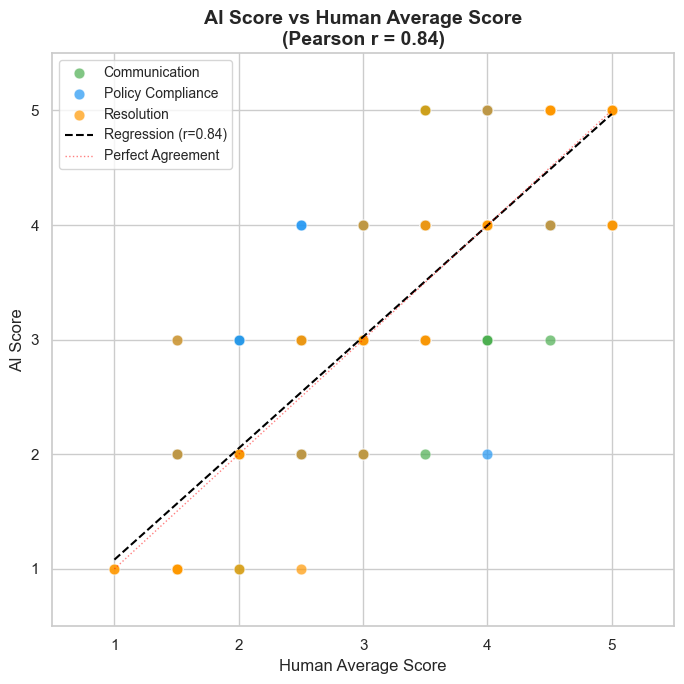

In [13]:
df['human_avg'] = (df['human1'] + df['human2']) / 2

colors_map = {'policy_compliance': '#2196F3', 'communication': '#4CAF50', 'resolution': '#FF9800'}

fig, ax = plt.subplots(figsize=(7, 7))

for criterion, group in df.groupby('criterion'):
    ax.scatter(group['human_avg'], group['ai'],
               label=criterion.replace('_', ' ').title(),
               color=colors_map[criterion], alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

# Regression line
m, b = np.polyfit(df['human_avg'], df['ai'], 1)
x_line = np.linspace(1, 5, 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--', label=f'Regression (r=0.84)')

# Perfect agreement line
ax.plot([1, 5], [1, 5], color='red', linewidth=1, linestyle=':', alpha=0.5, label='Perfect Agreement')

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xlabel('Human Average Score', fontsize=12)
ax.set_ylabel('AI Score', fontsize=12)
ax.set_title('AI Score vs Human Average Score\n(Pearson r = 0.84)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('scatter_correlation.png', dpi=150)
plt.show()